# Portfolio Optimization
Markowitz mean-variance optimization using Pyomo + IPOPT.

In [1]:
import yfinance as yf
import pandas as pd
import pyomo.environ as pyo
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 1. Configuration

In [2]:
# â”€â”€ Ticker selection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
selected_tickers = [
    # Individual stocks
    'SHEL.L', 'BP.L',                          # Energy
    'HSBA.L', 'BARC.L',                        # Financials
    'AZN.L',  'GSK.L',                         # Healthcare
    'ULVR.L', 'DGE.L',                         # Consumer Staples
    'RIO.L',                                   # Mining
    'BA.L',                                    # Defence
    'NG.L',                                    # Utilities
    'VOD.L',                                   # Telecoms
    # ETFs
    'ISF.L', 'VMID.L', 'HUKX.L',              # FTSE 100 / FTSE 250
]

# â”€â”€ Date range â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
start_date = '2019-10-01'
end_date   = '2024-10-31'

# â”€â”€ Optimization parameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
reward_floor      = 0.004  # minimum monthly return (~5% annualised; realistic for FTSE)
risk_free_rate    = 0.045  # annual risk-free rate (UK gilt proxy)

# â”€â”€ Dividend toggle â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# True  â†’ total return (price + reinvested dividends); recommended for income stocks
# False â†’ price-only return; strips out dividend contribution
include_dividends = True

## 2. Download & Prepare Returns Data

In [3]:
print("=== CELL V4 ===")

# Clear any stale yfinance SQLite cache locks
import pathlib, contextlib
for _db in pathlib.Path.home().glob("AppData/Local/py-yfinance/*.db"):
    with contextlib.suppress(Exception):
        _db.unlink()

# â”€â”€ Download prices â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# auto_adjust=True  â†’ Close = total return (price + reinvested dividends)
# auto_adjust=False â†’ bulk download is unreliable for LSE tickers;
#                     fall back to per-ticker history() calls which handle .L correctly
return_type = "total return (price + dividends)" if include_dividends else "price-only (dividends excluded)"

if include_dividends:
    # Bulk download works fine with auto_adjust=True
    data = yf.download(selected_tickers, start=start_date, end=end_date,
                       interval='1mo', auto_adjust=True, progress=False)
    print("data.columns type :", type(data.columns).__name__)
    print("First 8 columns   :", data.columns[:8].tolist())

    def _pick_col(available, prefer_adj):
        if prefer_adj and 'Adj Close' in available:
            return 'Adj Close'
        return 'Close'

    if isinstance(data.columns, pd.MultiIndex):
        l0 = set(data.columns.get_level_values(0).unique())
        l1 = set(data.columns.get_level_values(1).unique())
        if {'Close', 'Adj Close'} & l0:
            price_col = _pick_col(l0, True)
            df = data[price_col].copy()
        elif {'Close', 'Adj Close'} & l1:
            price_col = _pick_col(l1, True)
            df = data.xs(price_col, level=1, axis=1).copy()
        else:
            raise KeyError(f"No close-price column. Level 0: {l0}  Level 1: {l1}")
    else:
        price_col = _pick_col(data.columns, True)
        df = data[[price_col]].copy()

    print(f"Price column used : {price_col}  â†’  {return_type}")

else:
    # Per-ticker history() is reliable for LSE tickers with auto_adjust=False
    print("Downloading price-only data per ticker (auto_adjust=False)...")
    frames = {}
    for t in selected_tickers:
        try:
            hist = yf.Ticker(t).history(start=start_date, end=end_date,
                                         interval='1mo', auto_adjust=False)
            if not hist.empty and 'Close' in hist.columns:
                frames[t] = hist['Close']
            else:
                print(f"  WARNING: no data for {t}, skipping")
        except Exception as e:
            print(f"  WARNING: {t} failed ({e}), skipping")
    df = pd.DataFrame(frames)
    print(f"  Downloaded {len(frames)}/{len(selected_tickers)} tickers")
    print(f"Price column used : Close  â†’  {return_type}")

# â”€â”€ Format index â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df.index = pd.to_datetime(df.index).strftime('%b-%Y')

# â”€â”€ Clean in correct order â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df = df.dropna(axis=1, how='all')          # 1. drop tickers with NO data at all
df = df.pct_change().iloc[1:]              # 2. monthly returns (iloc[1:] drops the always-NaN first row)
df = df.dropna(axis=1, how='all')          # 3. drop any tickers still all-NaN after pct_change
df = df.dropna(axis=0, how='any')          # 4. drop months where any remaining ticker has a gap

# â”€â”€ Guard â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if df.shape[1] == 0:
    raise ValueError(
        "No assets left after cleaning â€” all tickers returned NaN. "
        "Check that the tickers are valid and the date range has data."
    )
if df.shape[0] == 0:
    raise ValueError(
        "No months left after cleaning â€” too many data gaps across tickers. "
        "Try a shorter date range or fewer tickers."
    )

print(f"Shape: {df.shape}  ({df.shape[0]} months, {df.shape[1]} assets)")
df.describe().round(4)

=== CELL V4 ===
data.columns type : MultiIndex
First 8 columns   : [('Close', 'AZN.L'), ('Close', 'BA.L'), ('Close', 'BARC.L'), ('Close', 'BP.L'), ('Close', 'DGE.L'), ('Close', 'GSK.L'), ('Close', 'HSBA.L'), ('Close', 'HUKX.L')]
Price column used : Close  â†’  total return (price + dividends)
Shape: (60, 15)  (60 months, 15 assets)


Ticker,AZN.L,BA.L,BARC.L,BP.L,DGE.L,GSK.L,HSBA.L,HUKX.L,ISF.L,NG.L,RIO.L,SHEL.L,ULVR.L,VMID.L,VOD.L
count,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000
mean,0.0080,0.0155,0.0119,-0.0012,-0.0032,-0.0021,0.0062,0.0025,0.0024,0.0028,0.0066,0.0055,0.0014,0.0040,-0.0101
std,0.0559,0.0729,0.1081,0.0805,0.0540,0.0620,0.0763,0.0396,0.0398,0.0539,0.0768,0.0800,0.0441,0.0586,0.0754
min,-0.1270,-0.1763,-0.3673,-0.1518,-0.1106,-0.2016,-0.1351,-0.1344,-0.1465,-0.1580,-0.1450,-0.1670,-0.1196,-0.2300,-0.2036
25%,-0.0227,-0.0190,-0.0571,-0.0513,-0.0475,-0.0291,-0.0461,-0.0144,-0.0221,-0.0204,-0.0535,-0.0379,-0.0236,-0.0252,-0.0474
50%,0.0118,0.0064,0.0231,0.0006,0.0024,0.0027,0.0052,0.0106,0.0104,0.0083,0.0062,0.0091,0.0051,0.0022,-0.0224
75%,0.0442,0.0485,0.0901,0.0385,0.0340,0.0337,0.0536,0.0266,0.0253,0.0444,0.0560,0.0520,0.0283,0.0448,0.0271
max,0.1533,0.2698,0.2628,0.2597,0.1525,0.0967,0.1963,0.1223,0.1242,0.1176,0.2310,0.3168,0.0992,0.1236,0.2008


## 3. Build Pyomo Model

In [4]:
model = pyo.ConcreteModel('Portfolio Management')

model.stocks = pyo.Set(initialize=df.columns.tolist())
model.p = pyo.Var(model.stocks, domain=pyo.NonNegativeReals)

# Pre-compute covariance matrix once (avoid repeated np.cov calls inside Pyomo)
cov = df.cov().values
stocks_list = df.columns.tolist()
cov_dict = {
    (stocks_list[i], stocks_list[j]): cov[i, j]
    for i in range(len(stocks_list))
    for j in range(len(stocks_list))
}
mean_ret = df.mean().to_dict()

# Objective: minimise portfolio variance
def portfolio_variance(m):
    return sum(
        cov_dict[i, j] * m.p[i] * m.p[j]
        for i in m.stocks for j in m.stocks
    )

model.min_risk = pyo.Objective(rule=portfolio_variance, sense=pyo.minimize)

# Constraint: minimum expected return
model.min_reward = pyo.Constraint(
    expr=sum(model.p[i] * mean_ret[i] for i in model.stocks) >= reward_floor
)

# Constraint: weights sum to 1
model.sum_allocs = pyo.Constraint(
    expr=sum(model.p[i] for i in model.stocks) == 1
)

print('Model built.')
model.pprint()

Model built.
1 Set Declarations
    stocks : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   15 : {'AZN.L', 'BA.L', 'BARC.L', 'BP.L', 'DGE.L', 'GSK.L', 'HSBA.L', 'HUKX.L', 'ISF.L', 'NG.L', 'RIO.L', 'SHEL.L', 'ULVR.L', 'VMID.L', 'VOD.L'}

1 Var Declarations
    p : Size=15, Index=stocks
        Key    : Lower : Value : Upper : Fixed : Stale : Domain
         AZN.L :     0 :  None :  None : False :  True : NonNegativeReals
          BA.L :     0 :  None :  None : False :  True : NonNegativeReals
        BARC.L :     0 :  None :  None : False :  True : NonNegativeReals
          BP.L :     0 :  None :  None : False :  True : NonNegativeReals
         DGE.L :     0 :  None :  None : False :  True : NonNegativeReals
         GSK.L :     0 :  None :  None : False :  True : NonNegativeReals
        HSBA.L :     0 :  None :  None : False :  True : NonNegativeReals
        HUKX.L :     0 :  None :  None : False :  True : Non

## 4. Solve
> **APPSI-IPOPT** if available (faster re-solves); falls back to classic SolverFactory.

In [5]:
import idaes, os

ipopt_exe = os.path.join(idaes.bin_directory, 'ipopt.exe')
solver = pyo.SolverFactory('ipopt', executable=ipopt_exe)
res = solver.solve(model, tee=False)
print('Solved via SolverFactory-IPOPT')
print(res.solver.termination_condition)

Solved via SolverFactory-IPOPT
optimal


## 5. Results

In [6]:
print("=== SECTION 5 v9 ===")
weights = {i: pyo.value(model.p[i]) for i in model.stocks}

weights_df = (pd.DataFrame.from_dict(weights, orient="index", columns=["Weight"]).sort_values("Weight", ascending=False))
weights_df["Weight %"] = (weights_df["Weight"] * 100).round(2)

print("Fetching dividend yields...", end=" ")
div_yields, ticker_names = {}, {}
for t in selected_tickers:
    try:
        info = yf.Ticker(t).info
        raw = info.get("dividendYield") or 0.0
        div_yields[t]   = raw if raw > 1 else raw * 100
        ticker_names[t] = info.get("longName") or info.get("shortName") or t
    except Exception:
        div_yields[t]   = 0.0
        ticker_names[t] = t
print("done.")

weights_df["Div Yield %"]     = pd.Series(div_yields).round(2)
weights_df["Wtd Div Yield %"] = (weights_df["Weight"] * weights_df["Div Yield %"]).round(3)
portfolio_div_yield = weights_df["Wtd Div Yield %"].sum()

# -- Total return: daily data (daily Dividends column is reliable for LSE).
# -- Price-only:   monthly data pct_change.
# -- Separated try/except so failure in one does not block the other.
frames_div, frames_po = {}, {}
for t in selected_tickers:
    # with-dividends: daily history compounded to monthly
    try:
        h = yf.Ticker(t).history(start=start_date, end=end_date, interval="1d", auto_adjust=False)
        if not h.empty and len(h) >= 5:
            c = h["Close"]
            r = (c.diff() + h["Dividends"]) / c.shift(1)
            r = r.iloc[1:].dropna()
            if r.index.tz is not None:
                r.index = pd.DatetimeIndex([ts.replace(tzinfo=None) for ts in r.index])
            frames_div[t] = (1 + r).resample("ME").prod() - 1
    except Exception as e:
        print(f"  div {t}: {e}")
    # price-only: monthly history
    try:
        h = yf.Ticker(t).history(start=start_date, end=end_date, interval="1mo", auto_adjust=False)
        if not h.empty:
            frames_po[t] = h["Close"].pct_change().iloc[1:]
    except Exception as e:
        print(f"  po  {t}: {e}")

print(f"frames_div: {len(frames_div)} tickers, frames_po: {len(frames_po)} tickers")

def clean_mean(frames):
    d = pd.DataFrame(frames)
    d.index = pd.to_datetime(d.index).strftime("%b-%Y")
    return d.dropna(axis=1, how="all").dropna(axis=0, how="any").mean().to_dict()

mean_ret_div_pt = clean_mean(frames_div)
mean_ret_po     = clean_mean(frames_po)

exp_ret_div    = (1 + sum(weights[i] * mean_ret_div_pt[i] for i in model.stocks if i in mean_ret_div_pt)) ** 12 - 1
exp_ret_no_div = (1 + sum(weights[i] * mean_ret_po[i]     for i in model.stocks if i in mean_ret_po))     ** 12 - 1

ann_std_div   = (pyo.value(model.min_risk) ** 0.5) * (12 ** 0.5)
sharpe_div    = (exp_ret_div    - risk_free_rate) / ann_std_div
sharpe_no_div = (exp_ret_no_div - risk_free_rate) / ann_std_div

print(f"Objective (portfolio variance)          : {pyo.value(model.min_risk):.6f}")
print(f"Expected yearly return  (with div)      : {exp_ret_div*100:.2f} %   Sharpe: {sharpe_div:.2f}")
print(f"Expected yearly return  (without div)   : {exp_ret_no_div*100:.2f} %   Sharpe: {sharpe_no_div:.2f}")
print(f"Portfolio weighted div yield            : {portfolio_div_yield:.2f} %  (trailing 12m)")
print()
print(weights_df[["Weight %", "Div Yield %", "Wtd Div Yield %"]].to_string())
print("Weights total :", round(weights_df["Weight %"].sum(), 1), "%")


=== SECTION 5 v9 ===
Fetching dividend yields... done.
frames_div: 15 tickers, frames_po: 15 tickers
Objective (portfolio variance)          : 0.000844
Expected yearly return  (with div)      : 10.16 %   Sharpe: 0.56
Expected yearly return  (without div)   : 5.93 %   Sharpe: 0.14
Portfolio weighted div yield            : 3.33 %  (trailing 12m)

        Weight %  Div Yield %  Wtd Div Yield %
ULVR.L     26.26         4.02            1.056
NG.L       20.63         3.58            0.738
AZN.L      12.56         1.58            0.198
BA.L       12.16         1.62            0.197
HSBA.L     10.58         4.20            0.444
RIO.L       7.20         4.11            0.296
DGE.L       6.12         4.31            0.264
HUKX.L      3.55         2.93            0.104
GSK.L       0.92         3.32            0.030
ISF.L       0.01         2.95            0.000
SHEL.L      0.00         3.21            0.000
VMID.L      0.00         4.05            0.000
VOD.L       0.00         3.36            0

## 6. Efficient Frontier

  15 tickers loaded
Computing frontier WITH dividends...
  Feasible points: 40
Computing frontier WITHOUT dividends...
  Feasible points: 40


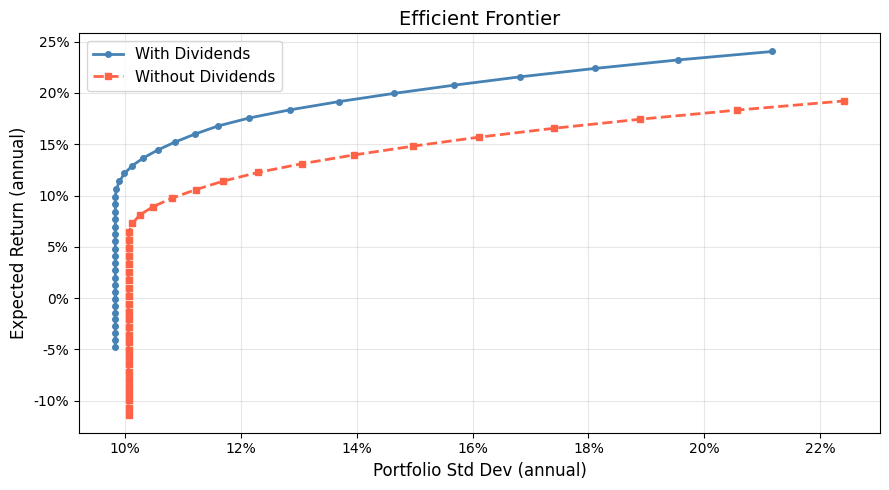

In [7]:
# -- Helper: compute efficient frontier ----------------------------------
def compute_frontier(mean_ret_d, cov_dict_d, stocks_list_d, n_points=40):
    if not mean_ret_d: return [], []
    min_f = min(mean_ret_d.values()) + 1e-4
    max_f = max(mean_ret_d.values()) * 0.95
    floors = np.linspace(min_f, max_f, n_points)
    vars_, rets_ = [], []
    for rf in floors:
        m2 = pyo.ConcreteModel()
        m2.stocks = pyo.Set(initialize=stocks_list_d)
        m2.p = pyo.Var(m2.stocks, domain=pyo.NonNegativeReals)
        m2.obj = pyo.Objective(
            expr=sum(cov_dict_d[i,j]*m2.p[i]*m2.p[j] for i in m2.stocks for j in m2.stocks),
            sense=pyo.minimize
        )
        m2.c1 = pyo.Constraint(expr=sum(m2.p[i]*mean_ret_d[i] for i in m2.stocks) >= rf)
        m2.c2 = pyo.Constraint(expr=sum(m2.p[i] for i in m2.stocks) == 1)
        try:
            res2 = pyo.SolverFactory("ipopt", executable=ipopt_exe).solve(m2, tee=False)
            if res2.solver.termination_condition == pyo.TerminationCondition.optimal:
                vars_.append(pyo.value(m2.obj))
                rets_.append(rf)
        except Exception:
            pass
    return vars_, rets_

# -- Build total-return data: daily history compounded to monthly ----------
# Same approach as Section 5: no cache clearing, daily Dividends is reliable
print("Downloading daily data for with-dividend frontier...")
frames_tr = {}
for t in selected_tickers:
    try:
        h = yf.Ticker(t).history(start=start_date, end=end_date, interval="1d", auto_adjust=False)
        if not h.empty and len(h) >= 5:
            c = h["Close"]
            r = (c.diff() + h["Dividends"]) / c.shift(1)
            r = r.iloc[1:].dropna()
            if r.index.tz is not None:
                r.index = pd.DatetimeIndex([ts.replace(tzinfo=None) for ts in r.index])
            frames_tr[t] = (1 + r).resample("ME").prod() - 1
    except Exception as e:
        print(f"  {t}: {e}")

df_tr = pd.DataFrame(frames_tr)
df_tr.index = df_tr.index.strftime("%b-%Y")
df_tr = df_tr.dropna(axis=1, how="all").dropna(axis=0, how="any")
stocks_tr = df_tr.columns.tolist()
cov_tr_vals = df_tr.cov().values
cov_dict_tr = {(stocks_tr[i], stocks_tr[j]): cov_tr_vals[i,j]
               for i in range(len(stocks_tr)) for j in range(len(stocks_tr))}
mean_ret_tr = df_tr.mean().to_dict()
print(f"  {len(stocks_tr)} tickers loaded")

# -- Frontier 1: with dividends ------------------------------------------
print("Computing frontier WITH dividends...")
var_div, ret_div = compute_frontier(mean_ret_tr, cov_dict_tr, stocks_tr)
print(f"  Feasible points: {len(ret_div)}")

# -- Frontier 2: without dividends (reuse mean_ret / cov_dict from Sec 2) -
print("Computing frontier WITHOUT dividends...")
var_nd, ret_nd = compute_frontier(mean_ret, cov_dict, stocks_list)
print(f"  Feasible points: {len(ret_nd)}")

# -- Convert monthly -> annual --------------------------------------------
ann_ret_div = [(1 + r) ** 12 - 1 for r in ret_div]
ann_std_div = [v ** 0.5 * 12 ** 0.5 for v in var_div]
ann_ret_nd  = [(1 + r) ** 12 - 1 for r in ret_nd]
ann_std_nd  = [v ** 0.5 * 12 ** 0.5 for v in var_nd]

# -- Plot -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ann_std_div, ann_ret_div, "o-",  color="steelblue", linewidth=2, markersize=4, label="With Dividends")
ax.plot(ann_std_nd,  ann_ret_nd,  "s--", color="tomato",    linewidth=2, markersize=4, label="Without Dividends")
ax.set_xlabel("Portfolio Std Dev (annual)", fontsize=12)
ax.set_ylabel("Expected Return (annual)", fontsize=12)
ax.set_title("Efficient Frontier", fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Correlation Heatmap

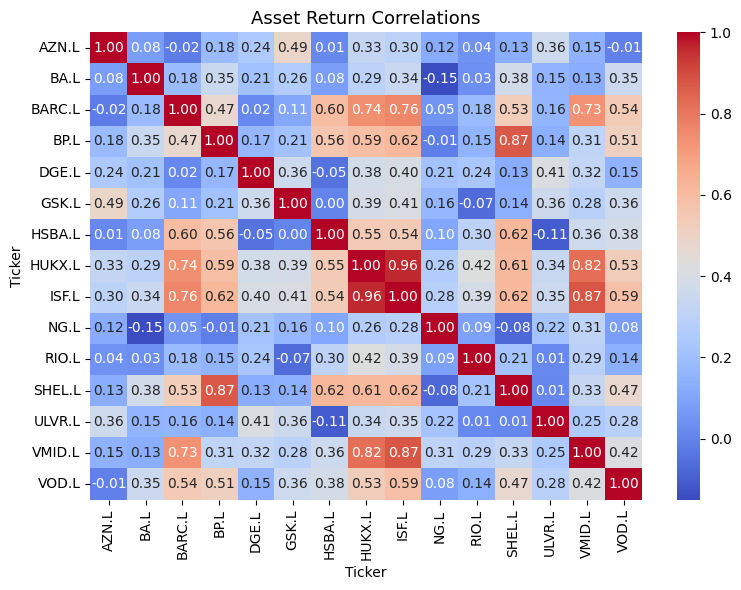

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Asset Return Correlations', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Optimal Weights â€” Bar Chart

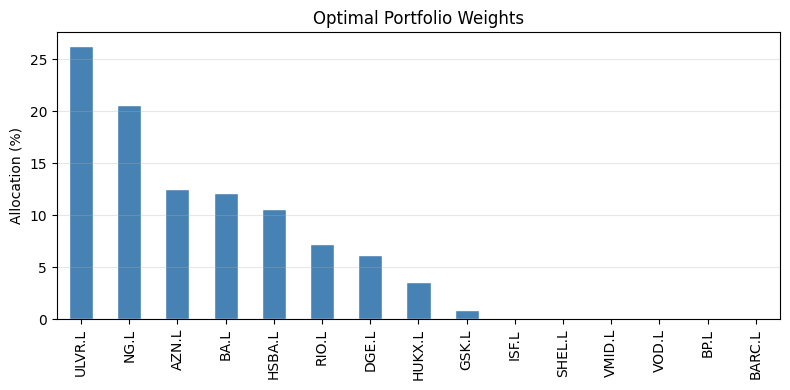

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
weights_df['Weight %'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_ylabel('Allocation (%)')
ax.set_title('Optimal Portfolio Weights')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Best 3-Asset Portfolio
Brute-force all C(n,3) combinations and pick the minimum-variance portfolio that meets the return floor.

In [10]:
from itertools import combinations
import logging
logging.getLogger("pyomo.core").setLevel(logging.ERROR)

assets = df.columns.tolist()
n_combos = len(list(combinations(assets, 3)))
print(f"Checking {n_combos} combinations of 3 assets...")

best_var, best_combo, best_weights, feasible = float("inf"), None, None, 0
solver3 = pyo.SolverFactory("ipopt", executable=ipopt_exe)

for combo in combinations(assets, 3):
    m3 = pyo.ConcreteModel()
    m3.stocks = pyo.Set(initialize=list(combo))
    m3.p = pyo.Var(m3.stocks, domain=pyo.NonNegativeReals)
    m3.obj = pyo.Objective(
        expr=sum(cov_dict[i,j]*m3.p[i]*m3.p[j] for i in m3.stocks for j in m3.stocks),
        sense=pyo.minimize
    )
    m3.c1 = pyo.Constraint(expr=sum(m3.p[i]*mean_ret[i] for i in m3.stocks) >= reward_floor)
    m3.c2 = pyo.Constraint(expr=sum(m3.p[i] for i in m3.stocks) == 1)
    try:
        res3 = solver3.solve(m3, tee=False, load_solutions=False)
        if res3.solver.termination_condition == pyo.TerminationCondition.optimal:
            m3.solutions.load_from(res3)
            feasible += 1
            v = pyo.value(m3.obj)
            if v < best_var:
                best_var = v
                best_combo = combo
                best_weights = {i: pyo.value(m3.p[i]) for i in m3.stocks}
    except Exception:
        pass

print(f"Feasible combinations : {feasible} / {n_combos}")
print()

# -- Fetch name and dividend yield for each asset in best combo
w3_df = pd.DataFrame.from_dict(best_weights, orient="index", columns=["Weight"])
w3_df["Weight %"] = (w3_df["Weight"] * 100).round(2)

# -- Names and div yields: use Section 5 data, fetch fresh if missing
import pathlib, contextlib
for _db in pathlib.Path.home().glob("AppData/Local/py-yfinance/*.db"):
    with contextlib.suppress(Exception): _db.unlink()

names, div3 = {}, {}
for t in best_combo:
    _name = (ticker_names or {}).get(t) if "ticker_names" in dir() else None
    _div  = (div_yields  or {}).get(t) if "div_yields"   in dir() else None
    if not _name or _name == t or not _div:
        try:
            info  = yf.Ticker(t).info
            _name = info.get("longName") or info.get("shortName") or t
            raw   = info.get("dividendYield") or 0.0
            _div  = raw if raw > 1 else raw * 100
        except Exception:
            _name = _name or t
            _div  = _div  or 0.0
    names[t] = _name
    div3[t]  = _div

w3_df["Company"]         = pd.Series(names)
w3_df["Div Yield %"]     = pd.Series(div3).round(2)
w3_df["Wtd Div Yield %"] = (w3_df["Weight"] * w3_df["Div Yield %"]).round(3)
portfolio_div3           = w3_df["Wtd Div Yield %"].sum()


# Use with-dividend means already computed in Section 5
_mean3 = mean_ret_div_pt if ("mean_ret_div_pt" in dir() and mean_ret_div_pt) else mean_ret
exp_ret_3 = (1 + sum(best_weights[i] * _mean3.get(i, 0) for i in best_combo)) ** 12 - 1
ann_std_3  = (best_var ** 0.5) * (12 ** 0.5)
sharpe_3   = (exp_ret_3 - risk_free_rate) / ann_std_3

print("=" * 55)
print("  Best 3-Asset Portfolio")
print("=" * 55)
print(f"  Portfolio variance     : {best_var:.6f}  (full: {pyo.value(model.min_risk):.6f})")
print(f"  Expected yearly return (with div) : {exp_ret_3*100:.2f} %   Sharpe: {sharpe_3:.2f}")
print(f"  Wtd dividend yield     : {portfolio_div3:.2f} %  (trailing 12m)")
print("=" * 55)
print()
cols = ["Company", "Weight %", "Div Yield %", "Wtd Div Yield %"]
print(w3_df[cols].to_string())
print()
print("Weights total :", round(w3_df["Weight %"].sum(), 1), "%")


Checking 455 combinations of 3 assets...
Feasible combinations : 399 / 455

  Best 3-Asset Portfolio
  Portfolio variance     : 0.001122  (full: 0.000844)
  Expected yearly return (with div) : 10.35 %   Sharpe: 0.50
  Wtd dividend yield     : 2.92 %  (trailing 12m)

                        Company  Weight %  Div Yield %  Wtd Div Yield %
BA.L            BAE Systems plc     16.52         1.62            0.268
HUKX.L  HSBC FTSE 100 UCITS ETF     51.32         2.93            1.504
NG.L          National Grid plc     32.16         3.58            1.151

Weights total : 100.0 %


## 10. Custom Portfolio Analyser


In [11]:
# ── USER INPUT: edit tickers and weights below ───────────────────────────
# Use "CASH" for a risk-free bond position yielding risk_free_rate.
custom_portfolio = {
    "ULVR.L":  0.25,
    "AZN.L":   0.25,
    "HSBA.L":  0.25,
    "CASH":    0.25,   # risk-free bond at risk_free_rate
}
# Weights must sum to 1.0 (will be normalised automatically if they don't)

# ─────────────────────────────────────────────────────────────────────────
CASH_KEY = "CASH"
rf_monthly = (1 + risk_free_rate) ** (1/12) - 1

total_w = sum(custom_portfolio.values())
if abs(total_w - 1.0) > 1e-6:
    print(f"Weights summed to {total_w:.4f} — normalising to 1.0")
    custom_portfolio = {t: w / total_w for t, w in custom_portfolio.items()}

cp_tickers = list(custom_portfolio.keys())
risky_tickers = [t for t in cp_tickers if t != CASH_KEY]
cash_weight   = custom_portfolio.get(CASH_KEY, 0.0)

# -- Download data for risky tickers (same method as Section 5 v9) --------
cp_frames_div, cp_frames_po = {}, {}
for t in risky_tickers:
    try:
        h = yf.Ticker(t).history(start=start_date, end=end_date, interval="1d", auto_adjust=False)
        if not h.empty and len(h) >= 5:
            c = h["Close"]
            r = (c.diff() + h["Dividends"]) / c.shift(1)
            r = r.iloc[1:].dropna()
            if r.index.tz is not None:
                r.index = pd.DatetimeIndex([ts.replace(tzinfo=None) for ts in r.index])
            cp_frames_div[t] = (1 + r).resample("ME").prod() - 1
    except Exception as e:
        print(f"  div {t}: {e}")
    try:
        h = yf.Ticker(t).history(start=start_date, end=end_date, interval="1mo", auto_adjust=False)
        if not h.empty:
            cp_frames_po[t] = h["Close"].pct_change().iloc[1:]
    except Exception as e:
        print(f"  po  {t}: {e}")

def clean_mean(frames):
    d = pd.DataFrame(frames)
    d.index = pd.to_datetime(d.index).strftime("%b-%Y")
    return d.dropna(axis=1, how="all").dropna(axis=0, how="any").mean().to_dict()

cp_mean_div = clean_mean(cp_frames_div)
cp_mean_po  = clean_mean(cp_frames_po)

# CASH contributes its fixed monthly return; zero variance / covariance
cp_mean_div[CASH_KEY] = rf_monthly
cp_mean_po[CASH_KEY]  = rf_monthly

# -- Portfolio variance (risky assets only; CASH has zero variance) --------
if cp_frames_div:
    cp_df = pd.DataFrame(cp_frames_div)
    cp_df.index = pd.to_datetime(cp_df.index).strftime("%b-%Y")
    cp_df = cp_df.dropna(axis=1, how="all").dropna(axis=0, how="any")
    cp_cov = cp_df.cov()
    cp_tickers_clean = cp_df.columns.tolist()
    port_var = sum(
        custom_portfolio.get(i, 0) * custom_portfolio.get(j, 0) * cp_cov.loc[i, j]
        for i in cp_tickers_clean for j in cp_tickers_clean
    )
else:
    port_var = 0.0

# -- Expected annual returns ----------------------------------------------
exp_ret_div = (1 + sum(custom_portfolio.get(t, 0) * cp_mean_div.get(t, 0)
                       for t in cp_tickers)) ** 12 - 1
exp_ret_po  = (1 + sum(custom_portfolio.get(t, 0) * cp_mean_po.get(t, 0)
                       for t in cp_tickers)) ** 12 - 1

ann_std = (port_var ** 0.5) * (12 ** 0.5) if port_var > 0 else 0.0
sharpe  = (exp_ret_div - risk_free_rate) / ann_std if ann_std > 0 else float("nan")

# -- Fetch company names and div yields for risky tickers -----------------
cp_names = {CASH_KEY: f"Risk-Free Bond ({risk_free_rate*100:.1f}%)"}
cp_divs  = {CASH_KEY: 0.0}
for t in risky_tickers:
    try:
        info = yf.Ticker(t).info
        cp_names[t] = info.get("longName") or info.get("shortName") or t
        raw = info.get("dividendYield") or 0.0
        cp_divs[t]  = raw if raw > 1 else raw * 100
    except Exception:
        cp_names[t] = t
        cp_divs[t]  = 0.0

# -- Display results ------------------------------------------------------
print("=" * 58)
print("  CUSTOM PORTFOLIO ANALYSIS")
print("=" * 58)
print(f"  Period : {start_date}  to  {end_date}")
print(f"  Risk-free rate        : {risk_free_rate*100:.2f} %")
print()

res_df = pd.DataFrame({
    "Company":     pd.Series({t: cp_names.get(t, t) for t in cp_tickers}),
    "Weight %":    pd.Series({t: round(custom_portfolio[t]*100, 2) for t in cp_tickers}),
    "Div Yield %": pd.Series({t: round(cp_divs.get(t, 0.0), 2) for t in cp_tickers}),
})
res_df["Wtd Div %"] = (res_df["Weight %"] / 100 * res_df["Div Yield %"]).round(3)
print(res_df.to_string(index=True))
print()
print(f"  Portfolio wtd div yield       : {res_df['Wtd Div %'].sum():.2f} %")
print(f"  Annual std dev                : {ann_std*100:.2f} %")
print()
print(f"  Expected yearly return (with div)    : {exp_ret_div*100:.2f} %")
print(f"  Expected yearly return (price only)  : {exp_ret_po*100:.2f} %")
print(f"  Sharpe ratio (with div)              : {sharpe:.2f}")
print("=" * 58)


  CUSTOM PORTFOLIO ANALYSIS
  Period : 2019-10-01  to  2024-10-31
  Risk-free rate        : 4.50 %

                      Company  Weight %  Div Yield %  Wtd Div %
ULVR.L           Unilever PLC      25.0         4.02      1.005
AZN.L         AstraZeneca PLC      25.0         1.58      0.395
HSBA.L      HSBC Holdings plc      25.0         4.20      1.050
CASH    Risk-Free Bond (4.5%)      25.0         0.00      0.000

  Portfolio wtd div yield       : 2.45 %
  Annual std dev                : 9.36 %

  Expected yearly return (with div)    : 8.42 %
  Expected yearly return (price only)  : 5.90 %
  Sharpe ratio (with div)              : 0.42
